# RSNA Knee Abnormality Detection - Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) for the RSNA Knee Abnormality Detection competition. We analyze:
1. **`train.csv`**: Study UIDs, free-text radiology reports, and sparse target labels.
2. **`train_series.csv`**: MRI series mapping, planes (Sagittal, Axial, Coronal), and fluid/fat suppression indicators.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = "data"
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the Datasets

In [12]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
series_df = pd.read_csv(os.path.join(DATA_DIR, "train_series.csv"))

print(f"train.csv shape: {train_df.shape}")
print(f"train_series.csv shape: {series_df.shape}")

train.csv shape: (4407, 14)
train_series.csv shape: (24371, 5)


## 2. Profiling `train.csv` (Sparsity & Label Distribution)

Let's see how many rows are labeled versus unlabeled. Recall that only a very small subset of studies have clinician annotations.

Number of labeled studies: 58 (1.32%)
Number of unlabeled studies: 4349 (98.68%)


C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_34288\45331792.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Labeled (Clinician Ground Truth)", "Unlabeled (Report Only)"], y=[num_labeled, num_unlabeled], palette="viridis")


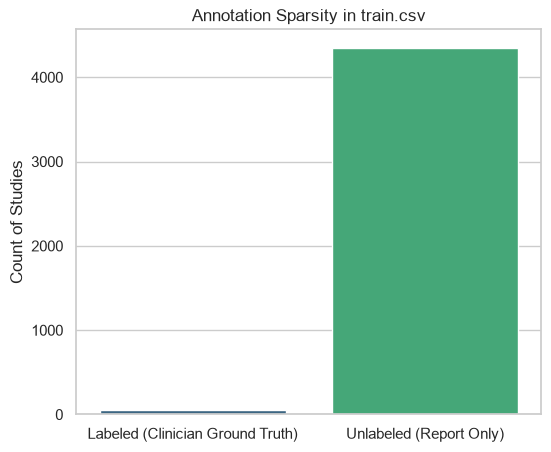

In [13]:
target_cols = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA", 
    "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"
]

# Check missing labels count
labeled_mask = train_df[target_cols].notnull().any(axis=1)
num_labeled = labeled_mask.sum()
num_unlabeled = len(train_df) - num_labeled

print(f"Number of labeled studies: {num_labeled} ({num_labeled/len(train_df)*100:.2f}%)")
print(f"Number of unlabeled studies: {num_unlabeled} ({num_unlabeled/len(train_df)*100:.2f}%)")

# Let's visualize this split
plt.figure(figsize=(6, 5))
sns.barplot(x=["Labeled (Clinician Ground Truth)", "Unlabeled (Report Only)"], y=[num_labeled, num_unlabeled], palette="viridis")
plt.title("Annotation Sparsity in train.csv")
plt.ylabel("Count of Studies")
plt.show()

### Target Labels Prevalence in the Labeled Subset
Let's inspect the positive and negative class counts for the 58 labeled studies.

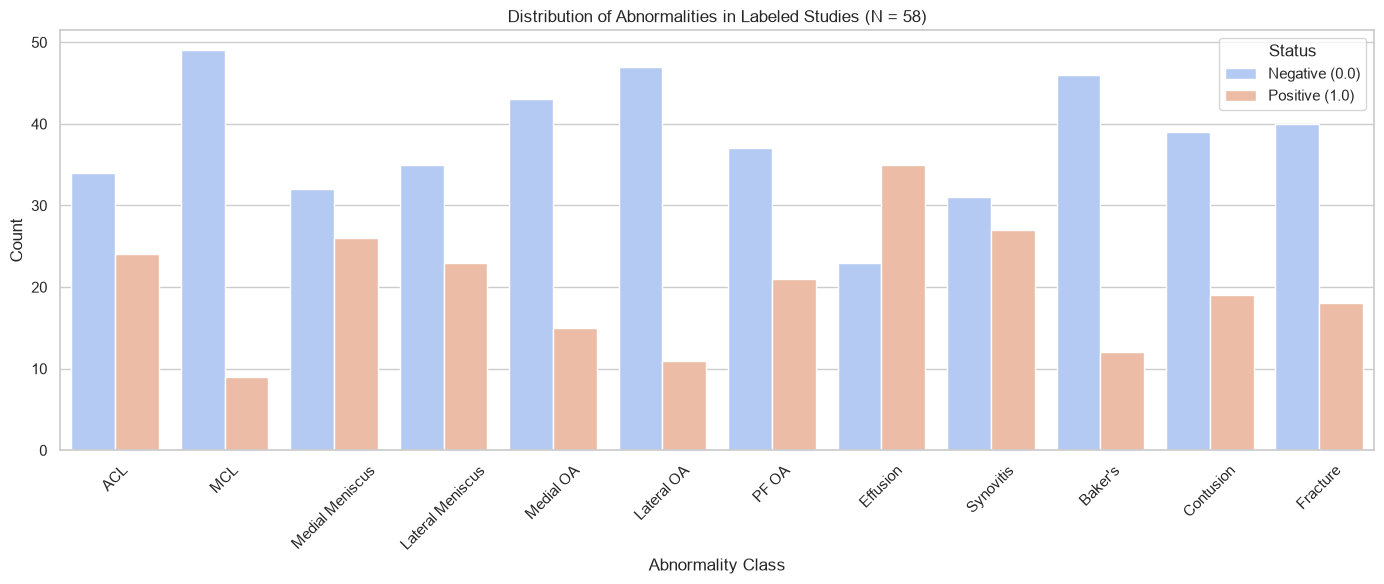

In [14]:
labeled_df = train_df[labeled_mask].copy()

# Melt the dataframe to make it easy to plot with seaborn
melted_df = pd.melt(labeled_df[target_cols])
melted_df["value"] = melted_df["value"].astype(str) # Convert labels to categorical strings for plotting

plt.figure(figsize=(14, 6))
sns.countplot(data=melted_df, x="variable", hue="value", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Distribution of Abnormalities in Labeled Studies (N = 58)")
plt.xlabel("Abnormality Class")
plt.ylabel("Count")
plt.legend(title="Status", labels=["Negative (0.0)", "Positive (1.0)"])
plt.tight_layout()
plt.show()

## 3. Profiling the Free-Text Reports

Since most of the dataset is unlabeled, we need to extract information from the `Report` column. Let's analyze report text lengths and view sample reports.

=== Report Length Summary (Characters) ===
count    4407.000000
mean     1097.905605
std       693.948925
min        52.000000
25%       587.500000
50%       977.000000
75%      1459.500000
max      4743.000000
Name: Report_Length, dtype: float64

=== Report Word Count Summary ===
count    4407.000000
mean      147.543000
std        95.329697
min         8.000000
25%        74.500000
50%       129.000000
75%       202.000000
max       690.000000
Name: Word_Count, dtype: float64


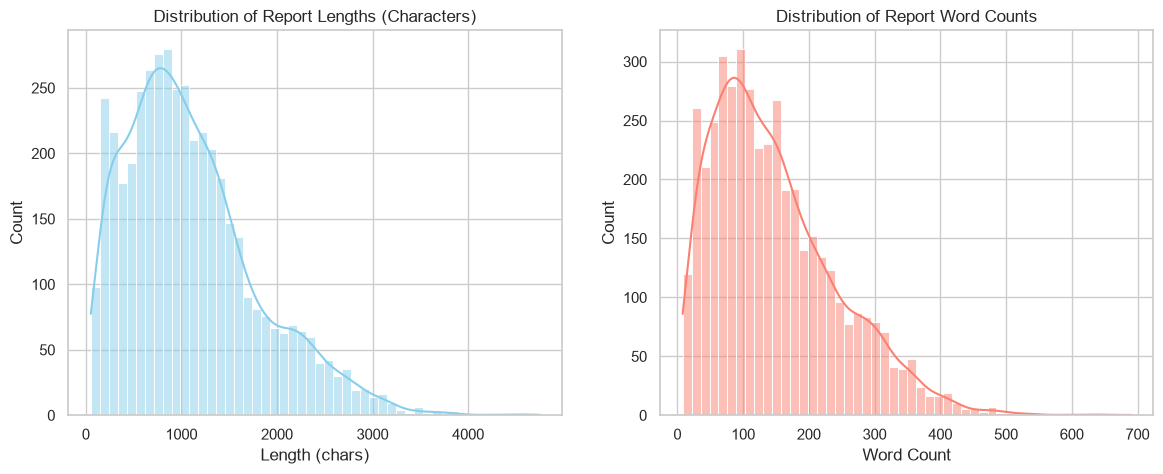

In [15]:
# Report length statistics
train_df["Report_Length"] = train_df["Report"].fillna("").apply(len)
train_df["Word_Count"] = train_df["Report"].fillna("").apply(lambda x: len(x.split()))

print("=== Report Length Summary (Characters) ===")
print(train_df["Report_Length"].describe())
print("\n=== Report Word Count Summary ===")
print(train_df["Word_Count"].describe())

# Length distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df["Report_Length"], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Report Lengths (Characters)")
axes[0].set_xlabel("Length (chars)")

sns.histplot(train_df["Word_Count"], bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribution of Report Word Counts")
axes[1].set_xlabel("Word Count")
plt.show()

### Sample Multilingual Reports
Let's print some reports of different lengths to see the variation in formatting and language.

In [16]:
print("=== Sample 1 (Short/Dutch) ===")
print(train_df.iloc[1]["Report"])
print("-" * 50)

print("=== Sample 2 (Spanish) ===")
print(train_df.iloc[2]["Report"][:400])
print("...")
print("-" * 50)

print("=== Sample 3 (Longer Report) ===")
long_report = train_df[train_df["Report_Length"] > 800].iloc[0]["Report"]
print(long_report[:500])
print("...")

=== Sample 1 (Short/Dutch) ===
[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaal? Scanprotocol (DRB) : sag intermediair gewogen seq zonder en met fs, ax/ cor pd gewogen seq fs, cor T1 gewogen seq Bevindingen:
--------------------------------------------------
=== Sample 2 (Spanish) ===
Hallazgos:
No hay alteraciones en significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Aumento de señal del cuerno posterior del menisco medial que no impresiona contactar con la
superficie articular, sin caracteres propios de rotura.
Menisco lateral de morfología y señal conservada, sin signos de rotura.
Úlceras condrales de espesor parcial con fenómenos
...
--------------------------------------------------
=== Sample 3 (Longer Report) ===
Hallazgos:
No hay alteraciones en significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Aumento de señal del cuern

## 4. Profiling `train_series.csv` (Series Metadata)

Each knee MRI study consists of multiple series. Let's analyze how many series exist per study, which planes are most common, and how parameters like fat suppression are configured.

=== Number of Series per Study ===
count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64


C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_34288\2195162810.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series_per_study, palette="muted")


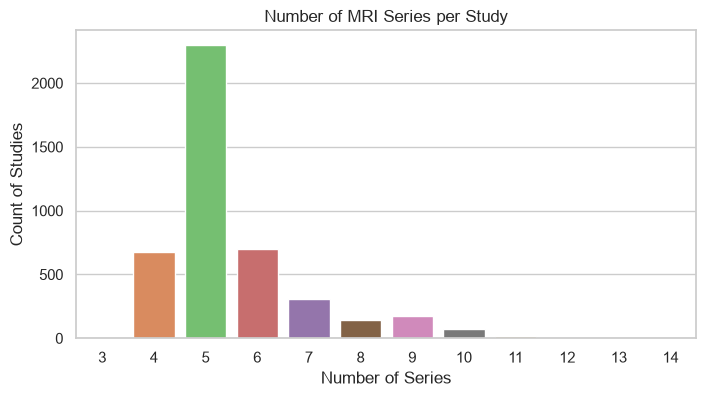

In [17]:
# 1. Number of series per study
series_per_study = series_df.groupby("StudyInstanceUID").size()
print("=== Number of Series per Study ===")
print(series_per_study.describe())

plt.figure(figsize=(8, 4))
sns.countplot(x=series_per_study, palette="muted")
plt.title("Number of MRI Series per Study")
plt.xlabel("Number of Series")
plt.ylabel("Count of Studies")
plt.show()

### Anatomical Planes & MRI Contrast Parameters

C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_34288\2723989214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=series_df, x="Anatomical_Plane", order=series_df["Anatomical_Plane"].value_counts().index, ax=axes[0], palette="Set2")
C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_34288\2723989214.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=series_df, x="Fluid_Sensitive", ax=axes[1], palette="pastel")
C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_34288\2723989214.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data

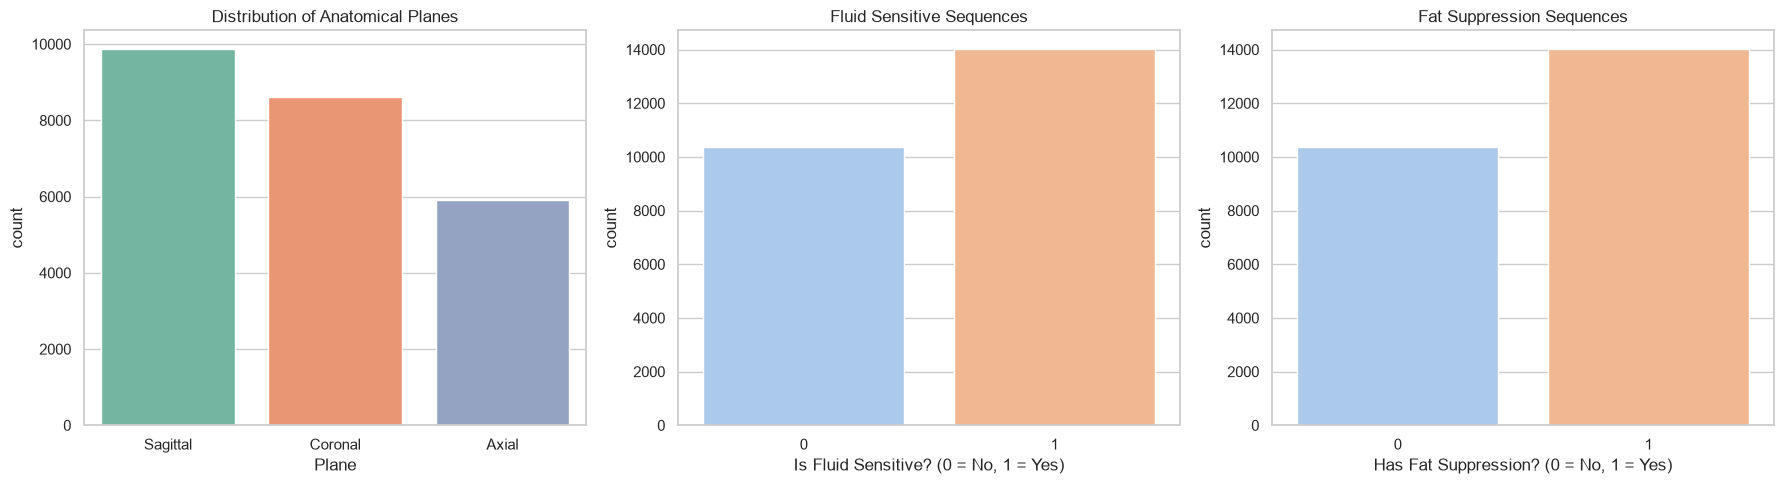

=== Cross-tabulation of Fluid Sensitive vs Fat Suppression ===
Fat_Suppression      0      1
Fluid_Sensitive              
0                10361      0
1                    0  14010


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plane Distribution
sns.countplot(data=series_df, x="Anatomical_Plane", order=series_df["Anatomical_Plane"].value_counts().index, ax=axes[0], palette="Set2")
axes[0].set_title("Distribution of Anatomical Planes")
axes[0].set_xlabel("Plane")

# Fluid Sensitivity
sns.countplot(data=series_df, x="Fluid_Sensitive", ax=axes[1], palette="pastel")
axes[1].set_title("Fluid Sensitive Sequences")
axes[1].set_xlabel("Is Fluid Sensitive? (0 = No, 1 = Yes)")

# Fat Suppression
sns.countplot(data=series_df, x="Fat_Suppression", ax=axes[2], palette="pastel")
axes[2].set_title("Fat Suppression Sequences")
axes[2].set_xlabel("Has Fat Suppression? (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

# Check correlation between Fluid Sensitive and Fat Suppression
cross_tab = pd.crosstab(series_df["Fluid_Sensitive"], series_df["Fat_Suppression"])
print("=== Cross-tabulation of Fluid Sensitive vs Fat Suppression ===")
print(cross_tab)

## 5. Main Takeaways from EDA

1. **Highly Unbalanced/Sparsely Annotated Targets:** Less than 1.5% of our dataset (58/4407) contains direct ground-truth classification labels. Designing a robust text keyword classifier (or pseudo-label generator) is critical to utilize the remaining 98.5% of studies.
2. **Multilingual Context:** Free-text reports are in multiple languages, demanding a multilingual keyword approach or multilingual LLM parser.
3. **Multi-Plane Input:** Studies typically contain 3 to 6 series across Axial, Coronal, and Sagittal views. A strong model needs to leverage these complementary planes or focus on the most diagnostic plane (like Sagittal for ACL/Meniscus).